# ODMR Analysis



<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [19]:
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
from lmfit.models import LorentzianModel, PolynomialModel
from scipy.signal import find_peaks
#import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.optimize import curve_fit

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;"> General Helpful Functions</h2>
</div>

In [2]:
def load_rabi_run(run_folder):
    data = np.load(run_folder / "rabi_data.npz")
    with open(run_folder / "metadata.json") as f:
        metadata = json.load(f)

    skip_keys = {"experiment_id", "timestamp"}
    run = {k: v for k, v in metadata.items() if k not in skip_keys}

    run["pulse_length_us"] = data["pulse_length_us"]
    run["signal1"] = data["signal1"]
    run["signal2"] = data["signal2"]
    run["reference1"] = data["reference1"]
    run["reference2"] = data["reference2"]
    run["diff"] = data["diff"]
    run["run_folder"] = run_folder

    return run


def load_all_rabi_runs(parent_dir):
    parent_dir = Path(parent_dir)
    runs = {}
    for run_folder in sorted(parent_dir.iterdir()):
        if not run_folder.is_dir():
            continue
        run_number = int(run_folder.name.split("_")[-1])
        runs[run_number] = load_rabi_run(run_folder)
    return runs

def plot_rabi_diff_overlay(runs, run_numbers, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    for run_number in run_numbers:
        run = runs[run_number]
        ax.plot(run["pulse_length_us"], run["diff"], label=f"run {run_number}", marker='o', markersize=3)

    ax.axhline(0, color='gray', linestyle='--')
    ax.set_xlabel("pulse length (us)")
    ax.set_ylabel("signal1 - signal2 (counts)")
    ax.legend()
    return ax


def plot_rabi_raw_signals(runs, run_number, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    run = runs[run_number]
    ax.plot(run["pulse_length_us"], run["signal1"], label="signal1 (MW pulse)")
    ax.plot(run["pulse_length_us"], run["signal2"], label="signal2 (no pulse)")
    ax.set_xlabel("pulse length (us)")
    ax.set_ylabel("Counts")
    ax.set_title(f"run {run_number}")
    ax.legend()
    return ax

def plot_rabi_run_scatter(runs, run_number, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    run = runs[run_number]
    ax.scatter(run["pulse_length_us"], run["diff"], s=20)
    ax.axhline(0, color='gray', linestyle='--')
    ax.set_xlabel("pulse length (us)")
    ax.set_ylabel("signal1 - signal2 (counts)")
    ax.set_title(f"Rabi run {run_number}")
    return ax

def plot_rabi_diff_overlay(runs, run_numbers, style='scatter', linestyle='-', offset=0, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    for i, run_number in enumerate(run_numbers):
        run = runs[run_number]
        t = run["pulse_length_us"]
        y = run["diff"] + i * offset

        if style == 'scatter':
            ax.scatter(t, y, s=20, label=f"run {run_number}")
        elif style == 'line':
            ax.plot(t, y, linestyle=linestyle, marker='o', markersize=4, label=f"run {run_number}")
        else:
            raise ValueError("style must be 'scatter' or 'line'")

    ax.axhline(0, color='gray', linestyle='--')
    ax.set_xlabel("pulse length (us)")
    ax.set_ylabel("signal1 - signal2 (counts)")
    ax.legend()
    return ax

def plot_rabi_run(runs, run_number, fields, style='scatter', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    if isinstance(fields, str):
        fields = [fields]

    run = runs[run_number]
    t = run["pulse_length_us"]

    for field in fields:
        y = run[field]
        if style == 'scatter':
            ax.scatter(t, y, s=20, label=field)
        elif style == 'line':
            ax.plot(t, y, label=field)
        else:
            raise ValueError("style must be 'scatter' or 'line'")

    ax.axhline(0, color='gray', linestyle='--')
    ax.set_xlabel("pulse length (us)")
    ax.set_ylabel("Counts")
    ax.set_title(f"Rabi run {run_number}")
    ax.legend()
    return ax

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Load Data</h2>
</div>

In [3]:
parent_dir = "/Volumes/hlab-nas/Data/DefectMsmts/Data/Albania/Rabi"
rabi_runs = load_all_rabi_runs(parent_dir)

print(list(rabi_runs.keys()))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Raw Data</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Plot Raw Data</h3>
</div>


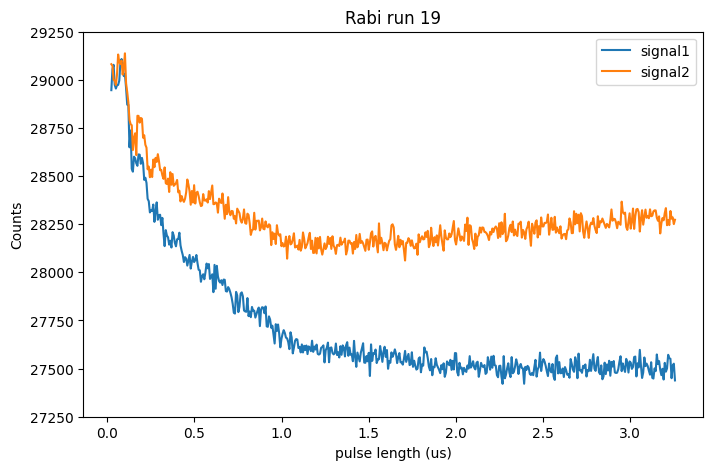

In [16]:
run_num = 19;
#plot_rabi_run(rabi_runs, run_num, ["signal1", "signal2", "reference1", "reference2", "diff"], style='scatter')
#plot_rabi_run(rabi_runs, run_num, ["signal1", "signal2", "reference1", "reference2"], style='scatter')
plot_rabi_run(rabi_runs, run_num, ["signal1", "signal2"], style='line')
plt.ylim(27250, 29250)
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Overlay</h3>
</div>


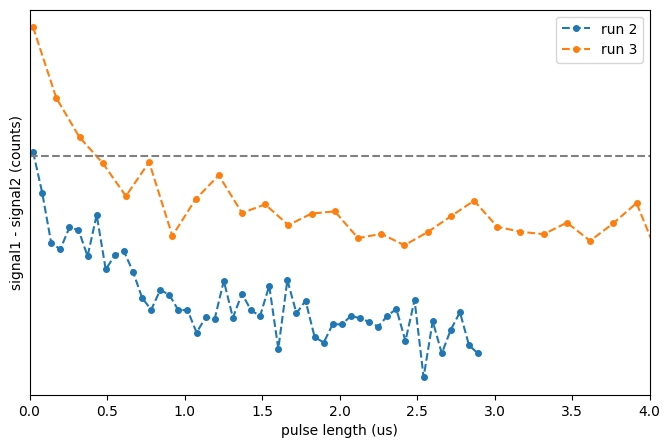

In [26]:
plot_rabi_diff_overlay(rabi_runs, [2, 3], style='line', linestyle='--',offset = 4000)
plt.gca().set_yticks([])
plt.xlim(0, 4)
plt.show()

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Analysis</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Fit Functions</h3>
</div>


In [17]:
def decaying_cos(t, amp, freq, tau, phase, offset):
    return amp * np.exp(-t / tau) * np.cos(2 * np.pi * freq * t + phase) + offset

def fit_rabi(run, p0=None):
    t = run["pulse_length_us"]
    diff = run["signal1"] - run["signal2"]

    if p0 is None:
        # rough auto guesses
        amp0 = (diff.max() - diff.min()) / 2
        offset0 = diff.mean()
        tau0 = (t.max() - t.min()) / 2
        # crude frequency guess from FFT peak
        dt = t[1] - t[0]
        fft_vals = np.abs(np.fft.rfft(diff - offset0))
        fft_freqs = np.fft.rfftfreq(len(diff), d=dt)
        freq0 = fft_freqs[np.argmax(fft_vals[1:]) + 1]  # skip DC bin
        p0 = [amp0, freq0, tau0, 0, offset0]

    popt, pcov = curve_fit(decaying_cos, t, diff, p0=p0, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))

    return popt, perr

def plot_rabi_fit(run, popt, run_num=None):
    t = run["pulse_length_us"]
    diff = run["signal1"] - run["signal2"]

    t_fit = np.linspace(t.min(), t.max(), 1000)
    fit_vals = decaying_cos(t_fit, *popt)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(t, diff, s=20, label="data")
    ax.plot(t_fit, fit_vals, color="red", label="fit")
    ax.axhline(0, color='gray', linestyle='--')
    ax.set_xlabel("pulse length (us)")
    ax.set_ylabel("signal1 - signal2 (counts)")
    title = "Rabi fit"
    if run_num is not None:
        title += f" — run {run_num}"
    ax.set_title(title)
    ax.legend()
    plt.show()

    amp, freq, tau, phase, offset = popt
    pi_time_us = 1 / (2 * freq) if freq != 0 else np.nan
    print(f"amp = {amp:.1f}, freq = {freq:.4f} MHz, tau = {tau:.3f} us, pi time ~ {pi_time_us:.3f} us")

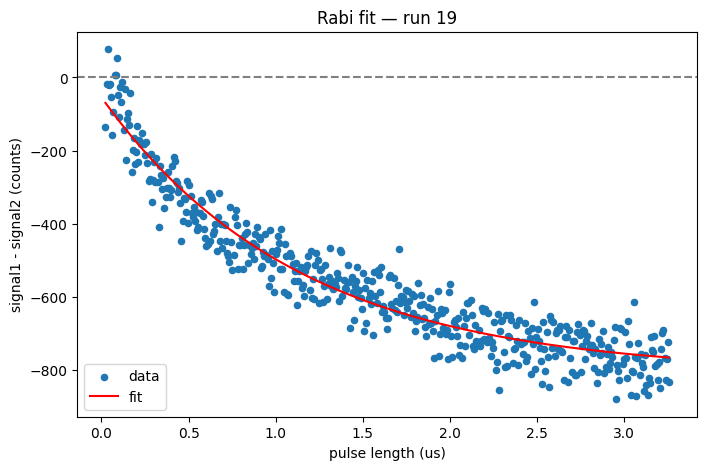

amp = 762.3, freq = 0.0000 MHz, tau = 1.129 us, pi time ~ 63881.371 us


In [20]:
popt, perr = fit_rabi(rabi_runs[run_num])
plot_rabi_fit(rabi_runs[run_num], popt, run_num=run_num)

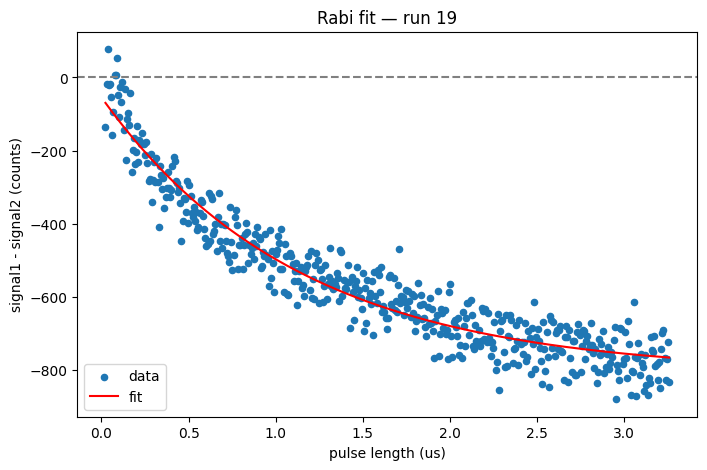

amp = 1200.2, freq = 0.0000 MHz, tau = 1.129 us, pi time ~ 670119.019 us


In [21]:
# example manual guess: amp, freq (MHz), tau (us), phase, offset
p0_manual = [3000, 0.5, 1.5, 0, -3000]
popt, perr = fit_rabi(rabi_runs[run_num], p0=p0_manual)
plot_rabi_fit(rabi_runs[run_num], popt, run_num=run_num)